# TF motif enrichment in FIRE regions

the goal is to compare the enrichment of transcription factor (TF) motifs in FIRE regions against a background set of genomic regions. We previously identified regions that have differential FIRE frequency (in either direction, can increase or decrease) between paired comparsion between time points. Now we want to see if there are any TF motifs that are enriched in these differential FIRE regions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import pysam
import pybedtools
from pathlib import Path
import re
import json
import hashlib
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, transforms
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.font_manager import FontProperties
from scipy import sparse
from scipy.stats import fisher_exact
from IPython.display import display

## prepare inputs for FIRE regions

the fire frequency code is in `/project/spott/cshan/fiber-seq/code/fire_frequency`

load FIRE  universe

In [2]:
# read in the FIRE universe
fire_univerise = pd.read_csv('/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/universe/fire_peaks_union.bed', sep='\t', header=None)

fire_univerise.head()

,0,1,2
0,chr1,11261,11486
1,chr1,21178,21359
2,chr1,28997,29166
3,chr1,29283,29478
4,chr1,29964,30121


load pairwise time points FIRE regions

1. the raw p values are calculated using a Fisher's exact test and are not adjusted for multiple testing. We will use a p value cutoff of 0.05 to select for significant FIRE regions

2. the coverage filter is based on the median read depth of the FIRE regions +/- 3 × square root of the median read depth

In [3]:
# read in pairwise time points FIRE regions

pairwise_fire_regions = pd.read_csv('/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/pairwise_fisher.tsv.gz', sep='\t', header=0)


# select for fire regions that pass the coverage filter (median read depth +/- 3 × square root of median read depth) and are significant
pairwise_fire_regions_differential = pairwise_fire_regions[(pairwise_fire_regions['pass_coverage'] == True) 
                                                       & (pairwise_fire_regions['p_value'] < 0.05)]

pairwise_fire_regions_background = pairwise_fire_regions[(pairwise_fire_regions['pass_coverage'] == True) 
                                                       & (pairwise_fire_regions['p_value'] > 0.05)]

In [6]:
pairwise_fire_regions_differential.head()

,chrom,start,end,region_id,comparison,n_reads_A,n_fire_A,freq_A,n_reads_B,n_fire_B,freq_B,delta_freq,log2_or,p_value,rank_p,pass_coverage
50,chr1,925600,925767,chr1:925600-925767,LPS_0_vs_LPS_5,38,5,0.131579,49,17,0.346939,0.215360,1.713573,0.026382,2503.0,True
62,chr1,1001921,1002079,chr1:1001921-1002079,LPS_0_vs_LPS_5,38,30,0.789474,40,38,0.950000,0.160526,2.101584,0.044803,4222.0,True
68,chr1,1020555,1020676,chr1:1020555-1020676,LPS_0_vs_LPS_5,30,2,0.066667,32,9,0.281250,0.214583,2.204301,0.044028,4138.0,True
100,chr1,1212929,1213135,chr1:1212929-1213135,LPS_0_vs_LPS_5,35,9,0.257143,32,2,0.062500,-0.194643,-2.128816,0.046993,4406.0,True
159,chr1,1693350,1693588,chr1:1693350-1693588,LPS_0_vs_LPS_5,28,20,0.714286,45,43,0.955556,0.241270,2.850926,0.005474,539.0,True


In [7]:
pairwise_fire_regions_background.head()

,chrom,start,end,region_id,comparison,n_reads_A,n_fire_A,freq_A,n_reads_B,n_fire_B,freq_B,delta_freq,log2_or,p_value,rank_p,pass_coverage
12,chr1,191690,191947,chr1:191690-191947,LPS_0_vs_LPS_5,45,16,0.355556,47,13,0.276596,-0.078960,-0.515388,0.502522,42909.0,True
23,chr1,605049,605189,chr1:605049-605189,LPS_0_vs_LPS_5,32,3,0.093750,52,6,0.115385,0.021635,0.236569,1.000000,79244.0,True
24,chr1,605205,605324,chr1:605205-605324,LPS_0_vs_LPS_5,35,8,0.228571,51,10,0.196078,-0.032493,-0.288825,0.790104,64630.0,True
25,chr1,605431,605663,chr1:605431-605663,LPS_0_vs_LPS_5,32,21,0.656250,51,34,0.666667,0.010417,0.076539,1.000000,79244.0,True
26,chr1,638325,638529,chr1:638325-638529,LPS_0_vs_LPS_5,48,11,0.229167,68,24,0.352941,0.123775,0.844233,0.217628,19067.0,True


get the differential FIRE regions that are gained and lost between time points

In [4]:
# function to get differential FIRE regions that are gained and lost
def get_gain_loss_FIRE_diff_regions(pairwise_fire_regions_differential, comparison):
    """
    Get differential FIRE regions gained and lost for one pairwise comparison.
    """

    # subset to this comparison
    filtered_df = pairwise_fire_regions_differential[
        pairwise_fire_regions_differential['comparison'] == comparison
    ]

    # delta_freq = later timepoint - earlier timepoint
    gained_FIRE = filtered_df[filtered_df['delta_freq'] > 0].copy()
    lost_FIRE = filtered_df[filtered_df['delta_freq'] < 0].copy()

    return gained_FIRE, lost_FIRE
    
    # get gained and lost FIRE regions
    gained_FIRE = filtered_df[filtered_df['delta_freq'] > 0]
    lost_FIRE = filtered_df[filtered_df['delta_freq'] < 0]
    
    return gained_FIRE, lost_FIRE

# loop over each pairwise time point comparison and get the gained and lost FIRE regions
gained_FIRE_regions = {}
lost_FIRE_regions = {}

comparisons = pairwise_fire_regions_differential['comparison'].unique()

for comparison in comparisons:

    gained, lost = get_gain_loss_FIRE_diff_regions(
        pairwise_fire_regions_differential,
        comparison
    )

    gained_FIRE_regions[comparison] = gained
    lost_FIRE_regions[comparison] = lost


check one example of 0min vs 15 min gained region

In [10]:
gained_FIRE_regions['LPS_0_vs_LPS_5']

,chrom,start,end,region_id,comparison,n_reads_A,n_fire_A,freq_A,n_reads_B,n_fire_B,freq_B,delta_freq,log2_or,p_value,rank_p,pass_coverage
50,chr1,925600,925767,chr1:925600-925767,LPS_0_vs_LPS_5,38,5,0.131579,49,17,0.346939,0.215360,1.713573,0.026382,2503.0,True
62,chr1,1001921,1002079,chr1:1001921-1002079,LPS_0_vs_LPS_5,38,30,0.789474,40,38,0.950000,0.160526,2.101584,0.044803,4222.0,True
68,chr1,1020555,1020676,chr1:1020555-1020676,LPS_0_vs_LPS_5,30,2,0.066667,32,9,0.281250,0.214583,2.204301,0.044028,4138.0,True
159,chr1,1693350,1693588,chr1:1693350-1693588,LPS_0_vs_LPS_5,28,20,0.714286,45,43,0.955556,0.241270,2.850926,0.005474,539.0,True
193,chr1,1944081,1944236,chr1:1944081-1944236,LPS_0_vs_LPS_5,37,26,0.702703,49,44,0.897959,0.195256,1.811943,0.026974,2565.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141714,chrX,144586780,144586970,chrX:144586780-144586970,LPS_0_vs_LPS_5,28,1,0.035714,30,8,0.266667,0.230952,2.792007,0.026138,2477.0,True
141951,chrX,150716919,150717110,chrX:150716919-150717110,LPS_0_vs_LPS_5,34,22,0.647059,31,28,0.903226,0.256167,2.177538,0.018859,1796.0,True
142569,chrY,4723286,4723472,chrY:4723286-4723472,LPS_0_vs_LPS_5,28,2,0.071429,39,16,0.410256,0.338828,2.895798,0.002073,213.0,True
142674,chrY,13361754,13361910,chrY:13361754-13361910,LPS_0_vs_LPS_5,29,1,0.034483,33,8,0.242424,0.207941,2.662965,0.029224,2768.0,True


### get sequence for the FIRE regions and background regions

In [5]:
hg38_path = "/project/spott/cshan/annotations/hg38.fa"
hg38_fasta = pysam.FastaFile(hg38_path)

get unique fire regions and background regions, and convert them into bed format

In [6]:
unique_differential_FIRE_regions = pairwise_fire_regions_differential[['chrom', 'start', 'end']].drop_duplicates().copy()
unique_background_FIRE_regions = pairwise_fire_regions_background[['chrom', 'start', 'end']].drop_duplicates().copy()

function to fetech sequence from FIRE regions

In [7]:
def fetch_sequences_from_fire_regions(fire_regions_df, fasta_file):
    """
    Fetch hg38 sequences for FIRE regions.
    """

    sequences = []

    for _, row in fire_regions_df.iterrows():
        chrom = row['chrom']
        start = int(row['start'])
        end = int(row['end'])

        sequence = fasta_file.fetch(
            chrom,
            start,
            end
        ).upper()

        sequences.append(sequence)

    fire_regions_df = fire_regions_df.copy()
    fire_regions_df['sequence'] = sequences

    return fire_regions_df


unique_differential_FIRE_regions = fetch_sequences_from_fire_regions(
    unique_differential_FIRE_regions,
    hg38_fasta
)

unique_background_FIRE_regions = fetch_sequences_from_fire_regions(
    unique_background_FIRE_regions,
    hg38_fasta
)

check the results of the FIRE feteched sequence

In [8]:
unique_differential_FIRE_regions.head()

,chrom,start,end,sequence
50,chr1,925600,925767,ACTCAGCCTTTCTGGGCCCGGCCTGCGGTTCCCTCGGGGCCGGGGA...
62,chr1,1001921,1002079,CCCAGGAGGTGGTGTGGATGGTGTCCCCGTCCCGCGTCCCTCCCCG...
68,chr1,1020555,1020676,TTGCTGCGCCGCCGCCGTCCTCCGCCCGCCGCCGCCTCCCTCCTCG...
100,chr1,1212929,1213135,ATCTGCGTCACAGACAGCCGCTATGCACACCCCCAACCGCCGGCCG...
159,chr1,1693350,1693588,GACACAAAGGCGCCTCCTGGCGGAAGTGGCCACGCTCCGCCCAGCC...


## Scan vertebrate TF motifs from JASPAR

The current scan uses `/project/spott/cshan/annotations/JASPAR2026_CORE_vertebrates_non-redundant_pfms_meme.txt` (1,019 motif profiles). Both groups are rescanned and existing FIMO outputs are overwritten on every submission. The enrichment section uses all scanned motifs without additional taxonomic filtering.


write fasta files for the differential FIRE regions and background regions

In [ ]:
# define the file path to save the differential FIRE regions with sequences 
output_dir = Path('/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/FIRE_region_fasta')

# save background and differential FIRE regions with sequences to fasta files
unique_differential_FIRE_regions.to_csv(
    output_dir / 'differential_FIRE_regions_with_sequences.tsv',
    sep='\t',
    index=False,
    header=True
)

unique_background_FIRE_regions.to_csv(
    output_dir / 'background_FIRE_regions_with_sequences.tsv',
    sep='\t',  
    index=False,
    header=True
)

run FIMO to scan for all TF motifs in the differential FIRE regions and background regions

In [10]:
# check if the fasta files already exist, and if they do directly use them for motif scanning

if (output_dir / 'differential_FIRE_regions_with_sequences.tsv').exists() and (output_dir / 'background_FIRE_regions_with_sequences.tsv').exists():
    print("Fasta files already exist. Using existing files for motif scanning.") 
else:
    # save background and differential FIRE regions with sequences to fasta files
    unique_differential_FIRE_regions.to_csv(
        output_dir / 'differential_FIRE_regions_with_sequences.tsv',
        sep='\t',
        index=False,
        header=True
    )

    unique_background_FIRE_regions.to_csv(
        output_dir / 'background_FIRE_regions_with_sequences.tsv',
        sep='\t',  
        index=False,
        header=True
    )   

Fasta files already exist. Using existing files for motif scanning.


--max-stored-scores sets the maximum number of motif occurrences that will be retained in memory

In [ ]:
%%writefile /project/spott/cshan/fiber-seq/code/fire_frequency/motif_fimo_scan.sh
#!/bin/bash
#SBATCH --job-name=fimo_fire_scan
#SBATCH --account=pi-spott
#SBATCH --partition=caslake
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=8
#SBATCH --mem=100G
#SBATCH --time=30:00:00
#SBATCH --output=/project/spott/cshan/fiber-seq/code/fire_frequency/fimo_%A_%a.out
#SBATCH --error=/project/spott/cshan/fiber-seq/code/fire_frequency/fimo_%A_%a.err

set -euo pipefail

FIRE_fasta_dir="/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/FIRE_region_fasta"
output_root="/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/tf_motif"

motif="/project/spott/cshan/annotations/JASPAR2026_CORE_vertebrates_non-redundant_pfms_meme.txt"
fimo="/project/spott/cshan/tools/meme-5.5.9-install/bin/fimo"

mkdir -p "${output_root}"

for group in differential background; do

    # Input TSV containing chrom, start, end, sequence
    input_tsv="${FIRE_fasta_dir}/${group}_FIRE_regions_with_sequences.tsv"

    # FASTA created from TSV
    fasta="${FIRE_fasta_dir}/${group}_FIRE_regions.fa"

    # FIMO output
    fimo_dir="${output_root}/fimo_${group}"
    fimo_tsv="${fimo_dir}/fimo.tsv"

    echo "========================================"
    echo "Processing ${group} FIRE regions"
    echo "========================================"

    # Check input TSV
    if [[ ! -s "${input_tsv}" ]]; then
        echo "ERROR: input TSV missing or empty:"
        echo "${input_tsv}"
        exit 1
    fi

    # Rebuild FASTA and rescan every group on each submission
    echo "Rebuilding FASTA from ${input_tsv}"
    awk 'BEGIN {FS=OFS="\t"}
         NR > 1 {
             print ">" $1 ":" $2 "-" $3
             print $4
         }' "${input_tsv}" > "${fasta}"

    # Run FIMO
    echo "Running FIMO..."

    "${fimo}" \
        --thresh 1e-4 \
        --max-stored-scores 10000000 \
        --oc "${fimo_dir}" \
        "${motif}" \
        "${fasta}"

    # Verify output
    if [[ ! -s "${fimo_tsv}" ]]; then
        echo "ERROR: FIMO did not create:"
        echo "${fimo_tsv}"
        exit 1
    fi

    echo "FIMO completed successfully:"
    echo "${fimo_tsv}"

done


In [2]:
%%bash

sbatch /project/spott/cshan/fiber-seq/code/fire_frequency/motif_fimo_scan.sh

sbatch: Verify job submission ...
sbatch: Using a shared partition ...
sbatch: Partition: caslake
sbatch: QOS-Flag: caslake
sbatch: Account: pi-spott
sbatch: Verification: ***PASSED***


Submitted batch job 59784563


## map motif to the TF

Run the import cell at the top of this notebook, then run every cell from this section to the end in order. All enrichment functions, tables, and plots are defined here; no external enrichment runner is needed.

The existing differential and background FIMO results are read directly. Run the earlier input-preparation and FIMO-submission cells only when generating new scans; using Run All also submits a new FIMO job.


In [5]:
analysis_root = Path('/project/spott/cshan/fiber-seq/macrophage_project/fire_frequency')
fasta_root = analysis_root / 'FIRE_region_fasta'
fimo_root = analysis_root / 'tf_motif'
motif_database = Path('/project/spott/cshan/annotations/JASPAR2026_CORE_vertebrates_non-redundant_pfms_meme.txt')
enrichment_dir = fimo_root / 'enrichment_vertebrates'
enrichment_dir.mkdir(parents=True, exist_ok=True)
fimo_threshold = 1e-4
fdr_threshold = 0.05
top_n = 100
# Current FASTA headers use BED start (0-based): >chrom:start-end.
# FIMO treats that start as 1-based, so its output numbers here need
# [start, stop+1) to map back to the ORIGINAL BED intervals.
fasta_headers_use_bed_start = True


Read the scanned vertebrate motif IDs, TF labels, and probability matrices

In [6]:
def read_meme_database(path):
    """Return motif annotations and A/C/G/T position-probability matrices."""
    lines = Path(path).read_text().splitlines()
    rows, matrices = [], {}
    motif_id = tf_name = None
    for i, line in enumerate(lines):
        if line.startswith('MOTIF '):
            fields = line.split(maxsplit=2)
            motif_id = fields[1]
            tf_name = fields[2] if len(fields) > 2 else motif_id
        elif line.startswith('letter-probability matrix:'):
            width = int(re.search(r'\bw=\s*(\d+)', line).group(1))
            matrix = np.array([list(map(float, row.split()))
                               for row in lines[i + 1:i + 1 + width]])
            if matrix.shape != (width, 4) or np.any(matrix < 0):
                raise ValueError(f'Invalid ACGT matrix: {motif_id}')
            if not np.allclose(matrix.sum(axis=1), 1, atol=1e-4):
                raise ValueError(f'Probability rows do not sum to 1: {motif_id}')
            if motif_id in matrices:
                raise ValueError(f'Duplicate motif ID: {motif_id}')
            matrices[motif_id] = matrix / matrix.sum(axis=1, keepdims=True)
            rows.append({'motif_id': motif_id, 'TF': tf_name, 'width': width})
    if not rows:
        raise ValueError(f'No motifs found in {path}')
    return pd.DataFrame(rows), matrices


In [7]:
motif_annotations, motif_probabilities = read_meme_database(motif_database)
motif_ids = motif_annotations['motif_id'].tolist()
motif_annotations.to_csv(enrichment_dir / 'motif_to_tf.tsv', sep='\t', index=False)
print(f'{len(motif_annotations):,}  motif profiles loaded.')
display(motif_annotations.head(10))


1,019  motif profiles loaded.


,motif_id,TF,width
0,MA0004.1,Arnt,6
1,MA0069.1,PAX6,14
2,MA0071.1,RORA,10
3,MA0074.1,RXRA::VDR,15
4,MA0101.1,REL,10
5,MA0107.1,RELA,10
6,MA0111.1,Spz1,11
7,MA0115.1,NR1H2::RXRA,17
8,MA0119.1,NFIC::TLX1,14
9,MA0130.1,ZNF354C,6


### Match TFs to RNA-seq expression and average biological replicates

Use STAR reverse-stranded gene counts (column 4), matching the existing RNA
analysis. Remove STAR's `N_` summary rows. Normalize each sample to **CPM using
its total gene-assigned reverse-stranded counts**, then take the arithmetic
mean of the three replicates at each included time point (0, 5, 10, 15 min).
Exclude 30 and 60 min before normalization, averaging, and expression filtering.
This is library-size normalization for expression detection, not a test of
differential RNA expression. Values are CPM, not TPM or DESeq2-normalized counts.

Map the STAR gene IDs to the exact GENCODE v46 reference and sum counts for gene IDs sharing a gene symbol

A motif is eligible when its TF has **mean CPM ≥ 5 in at least one included time point**.
    - For complexes, every component must meet the threshold in the same time point
    - Fisher tests and BH correction are performed on TF passing the expression filter


In [8]:
import io
rna_aligned_dir = Path('/project/spott/lizarraga/pacbio_analysis/macrophage_project/rna_seq/aligned')
rna_sample_sheet = rna_aligned_dir / 'sample_names.txt'
rna_gene_gtf = Path('/project/spott/lizarraga/human_references/gencode.v46.annotation.gtf')
expression_cpm_threshold = 5.0
expression_comparison = '>='
star_count_column = 'reverse'
expected_timepoints = [0, 5, 10, 15]
# Add only independently verified aliases as motif label -> GENCODE symbol.
tf_alias_overrides = {}


In [9]:
def read_rna_sample_sheet(path, aligned_dir):
    """Read sample/replicate/time metadata, including literal escaped tab separators."""
    text = Path(path).read_text().replace('\\t', '\t')
    samples = pd.read_csv(io.StringIO(text), sep='\t', dtype=str)
    samples.columns = samples.columns.str.strip()
    required = ['FILE NAME', 'REPLICATE', 'TIME']
    if not set(required) <= set(samples.columns):
        raise ValueError(f'Unexpected sample-sheet columns: {samples.columns.tolist()}')
    samples = samples[required].rename(columns={'FILE NAME': 'sample', 'REPLICATE': 'replicate', 'TIME': 'time_min'})
    for column in ['sample', 'replicate']:
        samples[column] = samples[column].str.strip()
    samples['time_min'] = pd.to_numeric(samples['time_min'].str.strip(), errors='raise').astype(int)
    samples = samples.loc[samples['time_min'].isin(expected_timepoints)].copy()
    if samples.isna().any().any() or samples['sample'].duplicated().any() or samples.duplicated(['time_min', 'replicate']).any():
        raise ValueError('Missing or duplicate sample/replicate/time entries')
    if sorted(samples['time_min'].unique()) != expected_timepoints:
        raise ValueError('RNA-seq time points do not match the configured time course')
    if not (samples.groupby('time_min').size() == 3).all():
        raise ValueError('Expected three biological replicates at every time point')
    samples['count_file'] = [str(aligned_dir / sample / f'{sample}_ReadsPerGene.out.tab')
                             for sample in samples['sample']]
    missing = [p for p in samples['count_file'] if not Path(p).is_file()]
    if missing:
        raise FileNotFoundError(f'Missing STAR counts: {missing}')
    return samples.sort_values(['time_min', 'replicate']).reset_index(drop=True)


In [10]:
rna_samples = read_rna_sample_sheet(rna_sample_sheet, rna_aligned_dir)
display(rna_samples[['sample', 'replicate', 'time_min']])
display(rna_samples.groupby('time_min')['replicate'].agg(list).rename('replicates').to_frame())
rna_samples.to_csv(enrichment_dir / 'rna_samples.tsv', sep='\t', index=False)


,sample,replicate,time_min
0,SP-AL-18s-R10_S1,R1,0
1,SP-AL-18s-R20_S7,R2,0
2,SP-AL-18s-R30_S13,R3,0
3,SP-AL-18s-R15_S5,R1,5
4,SP-AL-18s-R25_S11,R2,5
5,SP-AL-18s-R35_S17,R3,5
6,SP-AL-18s-R110_S2,R1,10
7,SP-AL-18s-R210_S8,R2,10
8,SP-AL-18s-R310_S14,R3,10
9,SP-AL-18s-R115_S3,R1,15


,replicates
time_min,
0,"[R1, R2, R3]"
5,"[R1, R2, R3]"
10,"[R1, R2, R3]"
15,"[R1, R2, R3]"


In [11]:
def load_star_gene_counts(samples, count_column='reverse'):
    """Load gene counts in a consistent order and inspect strandedness per sample."""
    counts = {}
    qc_rows = []
    reference_ids = None
    for row in samples.itertuples(index=False):
        data = pd.read_csv(row.count_file, sep='\t', header=None,
                           names=['gene_id', 'unstranded', 'forward', 'reverse'])
        genes = data.loc[~data['gene_id'].str.startswith('N_')].set_index('gene_id')
        if genes.index.has_duplicates or genes.empty:
            raise ValueError(f'{row.sample}: duplicate or absent gene IDs')
        values = genes.to_numpy(dtype=float)
        if not np.isfinite(values).all() or (values < 0).any() or not np.equal(values, np.floor(values)).all():
            raise ValueError(f'{row.sample}: invalid STAR counts')
        if reference_ids is None:
            reference_ids = genes.index
        if set(genes.index) != set(reference_ids):
            raise ValueError(f'{row.sample}: different gene inventory')
        genes = genes.reindex(reference_ids)
        sums = genes.sum()
        if sums[count_column] <= 0:
            raise ValueError(f'{row.sample}: zero assigned counts')
        if count_column == 'reverse' and sums['reverse'] <= sums['forward']:
            raise ValueError(f'{row.sample}: reverse-stranded counts do not dominate; inspect library strandedness')
        counts[row.sample] = genes[count_column].astype(np.int64)
        qc_rows.append({'sample': row.sample, 'time_min': row.time_min,
                        'unstranded_assigned': int(sums['unstranded']),
                        'forward_assigned': int(sums['forward']),
                        'reverse_assigned': int(sums['reverse']),
                        'reverse_to_forward_ratio': sums['reverse'] / max(1, sums['forward'])})
    return pd.DataFrame(counts), pd.DataFrame(qc_rows)


In [12]:
# Read sample metadata here so this cell does not depend on the preview cell having run.
rna_samples = read_rna_sample_sheet(rna_sample_sheet, rna_aligned_dir)
rna_counts, rna_count_qc = load_star_gene_counts(rna_samples, star_count_column)
print(f'Loaded {rna_counts.shape[0]:,} genes from {rna_counts.shape[1]} RNA-seq libraries.')
display(rna_count_qc)
display(rna_counts.iloc[:5, :6])
rna_count_qc.to_csv(enrichment_dir / 'rna_count_qc.tsv', sep='\t', index=False)


Loaded 63,086 genes from 12 RNA-seq libraries.


,sample,time_min,unstranded_assigned,forward_assigned,reverse_assigned,reverse_to_forward_ratio
0,SP-AL-18s-R10_S1,0,63323256,5122178,66993670,13.079137
1,SP-AL-18s-R20_S7,0,55163858,5043428,58347442,11.569005
2,SP-AL-18s-R30_S13,0,54335352,4857458,57502710,11.838025
3,SP-AL-18s-R15_S5,5,52972613,4371905,55970571,12.802330
4,SP-AL-18s-R25_S11,5,51880572,4578249,54813913,11.972681
5,SP-AL-18s-R35_S17,5,54118581,4687957,57243810,12.210822
6,SP-AL-18s-R110_S2,10,53179019,4490475,56174050,12.509601
7,SP-AL-18s-R210_S8,10,61209796,5100861,64439330,12.633030
8,SP-AL-18s-R310_S14,10,54307272,4469835,57273210,12.813272
9,SP-AL-18s-R115_S3,15,58528351,4778405,61991017,12.973161


,SP-AL-18s-R10_S1,SP-AL-18s-R20_S7,SP-AL-18s-R30_S13,SP-AL-18s-R15_S5,SP-AL-18s-R25_S11,SP-AL-18s-R35_S17
gene_id,,,,,,
ENSG00000290825.1,3,5,4,3,3,4
ENSG00000223972.6,0,0,0,0,0,0
ENSG00000227232.6,875,1006,906,831,768,823
ENSG00000278267.1,1,8,8,2,4,5
ENSG00000243485.5,7,0,1,1,1,0


In [13]:
def read_gtf_gene_symbols(path):
    """Stream gene features from the alignment GTF; do not load all exon records."""
    records = []
    with Path(path).open() as handle:
        for line in handle:
            if line.startswith('#'):
                continue
            fields = line.rstrip('\n').split('\t', 8)
            if len(fields) != 9 or fields[2] != 'gene':
                continue
            attrs = dict(re.findall(r'(\w+) "([^"]*)"', fields[8]))
            if 'gene_id' in attrs and 'gene_name' in attrs:
                records.append({'gene_id': attrs['gene_id'], 'gene_name': attrs['gene_name'],
                                'gene_type': attrs.get('gene_type', '')})
    annotation = pd.DataFrame(records)
    if annotation.empty or annotation['gene_id'].duplicated().any():
        raise ValueError('Empty GTF annotation or ambiguous duplicate gene IDs')
    return annotation


In [14]:
rna_gene_annotation = read_gtf_gene_symbols(rna_gene_gtf)
print(f'{rna_gene_annotation["gene_id"].isin(rna_counts.index).sum():,} count-matrix gene IDs have GENCODE symbols.')
display(rna_gene_annotation.head())


63,086 count-matrix gene IDs have GENCODE symbols.


,gene_id,gene_name,gene_type
0,ENSG00000290825.1,DDX11L2,lncRNA
1,ENSG00000223972.6,DDX11L1,transcribed_unprocessed_pseudogene
2,ENSG00000227232.6,WASH7P,unprocessed_pseudogene
3,ENSG00000278267.1,MIR6859-1,miRNA
4,ENSG00000243485.5,MIR1302-2HG,lncRNA


In [15]:
def average_gene_expression_by_time(counts, samples, annotation):
    """Normalize each library to CPM, sum gene IDs by symbol, then average replicates."""
    symbols = annotation.set_index('gene_id')['gene_name'].reindex(counts.index)
    matched = symbols.notna()
    if not matched.any():
        raise ValueError('No exact gene IDs match the RNA-seq GTF')
    library_sizes = counts.sum(axis=0)
    gene_cpm = counts.divide(library_sizes, axis=1) * 1e6
    symbol_cpm = gene_cpm.loc[matched].groupby(symbols.loc[matched], sort=True).sum()
    sample_time = samples.set_index('sample')['time_min']
    mean_cpm = symbol_cpm.T.groupby(sample_time.reindex(symbol_cpm.columns)).mean().T
    mean_cpm = mean_cpm.reindex(columns=expected_timepoints)
    mean_cpm.index.name = 'gene_name'
    mean_cpm.columns.name = 'time_min'
    return symbol_cpm, mean_cpm, symbols.loc[~matched].index.tolist()


In [16]:
gene_sample_cpm, gene_time_mean_cpm, unannotated_rna_genes = average_gene_expression_by_time(
    rna_counts, rna_samples, rna_gene_annotation
)
gene_time_mean_cpm.to_csv(enrichment_dir / 'gene_mean_cpm_by_time.tsv', sep='\t')
pd.Series(unannotated_rna_genes, name='gene_id').to_csv(enrichment_dir / 'rna_genes_without_symbol.tsv', sep='\t', index=False)
print(f'{len(gene_time_mean_cpm):,} gene symbols; {len(unannotated_rna_genes)} count IDs without annotation.')
print('Inspecting mean CPM for representative macrophage TFs:')
representative_tfs = [gene for gene in ['SPI1', 'CEBPB', 'JUN', 'FOS', 'RELA', 'NFKB1', 'IRF1']
                      if gene in gene_time_mean_cpm.index]
display(gene_time_mean_cpm.loc[representative_tfs].round(2))


61,471 gene symbols; 0 count IDs without annotation.
Inspecting mean CPM for representative macrophage TFs:


time_min,0,5,10,15
gene_name,,,,
SPI1,198.49,189.94,191.12,191.34
CEBPB,92.68,90.65,95.67,88.04
JUN,250.84,243.64,271.96,335.41
FOS,46.48,46.73,50.98,68.08
RELA,81.05,80.87,78.92,83.57
NFKB1,67.95,68.03,65.69,67.06
IRF1,69.72,69.08,66.04,69.93


In [25]:
def annotate_motif_expression(motif_table, mean_cpm, threshold=5.0):
    """Match TF components and require expression at a common time point for complexes."""
    symbol_lookup = {}
    for symbol in mean_cpm.index:
        symbol_lookup.setdefault(symbol.upper(), []).append(symbol)
    rows, components = [], []
    for row in motif_table.itertuples(index=False):
        labels = [re.sub(r'\s*\(var\.\d+\)$', '', label).strip() for label in row.TF.split('::')]
        resolved, unmapped = [], []
        for label in labels:
            query = tf_alias_overrides.get(label, label)
            candidates = symbol_lookup.get(query.upper(), [])
            symbol = candidates[0] if len(candidates) == 1 else None
            if symbol is None:
                unmapped.append(label)
            else:
                resolved.append(symbol)
            components.append({'motif_id': row.motif_id, 'TF': row.TF, 'component': label,
                               'gene_name': symbol,
                               'mapping': 'explicit alias' if symbol and label in tf_alias_overrides
                               else 'symbol (case-insensitive)' if symbol else 'unmapped or ambiguous'})
        if unmapped:
            values = pd.Series(np.nan, index=mean_cpm.columns)
            passed = pd.Series(False, index=mean_cpm.columns)
            mapping_status = 'partially mapped' if resolved else 'unmapped'
        else:
            # For complexes this is the least-expressed component at each time.
            values = mean_cpm.loc[resolved].min(axis=0)
            passed = values.ge(threshold) if expression_comparison == '>=' else values.gt(threshold)
            mapping_status = 'mapped'
        record = {'motif_id': row.motif_id, 'TF': row.TF,
                  'tf_genes': ';'.join(dict.fromkeys(resolved)),
                  'unmapped_components': ';'.join(unmapped), 'mapping_status': mapping_status,
                  'expressed_any_time': bool(passed.any()),
                  'expressed_timepoints': ';'.join(str(t) for t in mean_cpm.columns[passed]),
                  'max_component_min_mean_cpm': values.max()}
        record.update({f'mean_cpm_{time}min': value for time, value in values.items()})
        rows.append(record)
    return pd.DataFrame(rows), pd.DataFrame(components)


In [26]:

motif_annotations, motif_probabilities = read_meme_database(motif_database)
motif_ids = motif_annotations['motif_id'].tolist()

# Prepare both expression tables even if the preceding preview cell was skipped.
if 'rna_gene_annotation' not in globals():
    rna_gene_annotation = read_gtf_gene_symbols(rna_gene_gtf)
gene_sample_cpm, gene_time_mean_cpm, unannotated_rna_genes = average_gene_expression_by_time(
    rna_counts, rna_samples, rna_gene_annotation
)

motif_expression, motif_tf_components = annotate_motif_expression(
    motif_annotations, gene_time_mean_cpm, expression_cpm_threshold
)
motif_expression.to_csv(enrichment_dir / 'motif_tf_expression_filter.tsv', sep='\t', index=False)
motif_tf_components.to_csv(enrichment_dir / 'motif_tf_gene_mapping.tsv', sep='\t', index=False)
motif_expression.loc[motif_expression['mapping_status'] != 'mapped'].to_csv(
    enrichment_dir / 'motifs_with_unmapped_tf_labels.tsv', sep='\t', index=False
)
mapped_tf_genes = sorted(set(motif_tf_components['gene_name'].dropna()))
gene_sample_cpm.loc[mapped_tf_genes].to_csv(enrichment_dir / 'tf_cpm_by_replicate.tsv', sep='\t')
gene_time_mean_cpm.loc[mapped_tf_genes].to_csv(enrichment_dir / 'tf_mean_cpm_by_time.tsv', sep='\t')
print(f'{motif_expression["expressed_any_time"].sum():,} of {len(motif_expression):,} motifs pass the expression filter.')
display(motif_expression.groupby(['mapping_status', 'expressed_any_time']).size().rename('motifs').to_frame())
display(motif_expression.loc[motif_expression['expressed_any_time']].head(10))
print('Unmapped labels to review (not silently assigned to another TF):')
display(motif_expression.loc[motif_expression['mapping_status'] != 'mapped',
                              ['motif_id', 'TF', 'unmapped_components']].head(20))


514 of 1,019 motifs pass the expression filter.


motifs
mapping_status expressed_any_time        
mapped         False                  495
               True                   514
unmapped       False                   10

,motif_id,TF,tf_genes,unmapped_components,mapping_status,expressed_any_time,expressed_timepoints,max_component_min_mean_cpm,mean_cpm_0min,mean_cpm_5min,mean_cpm_10min,mean_cpm_15min
0,MA0004.1,Arnt,ARNT,,mapped,True,0;5;10;15,88.753619,87.022900,87.492756,84.512927,88.753619
3,MA0074.1,RXRA::VDR,RXRA;VDR,,mapped,True,0;5;10;15,12.685174,12.533401,11.668266,12.685174,11.967121
4,MA0101.1,REL,REL,,mapped,True,0;5;10;15,22.800974,20.995554,21.641931,21.288950,22.800974
5,MA0107.1,RELA,RELA,,mapped,True,0;5;10;15,83.567722,81.048324,80.865040,78.924501,83.567722
7,MA0115.1,NR1H2::RXRA,NR1H2;RXRA,,mapped,True,0;5;10;15,60.970686,60.970686,58.691882,58.960923,57.742821
9,MA0130.1,ZNF354C,ZNF354C,,mapped,True,0;5;10;15,12.934087,11.986869,12.527465,11.923325,12.934087
12,MA0151.1,Arid3a,ARID3A,,mapped,True,0;5;10;15,92.283446,92.283446,88.205788,91.925580,85.898789
14,MA0159.1,RARA::RXRA,RARA;RXRA,,mapped,True,0;5;10;15,53.698033,53.698033,49.971569,52.397784,50.726159
15,MA0163.1,PLAG1,PLAG1,,mapped,True,0;5;10;15,12.718949,11.154906,12.199886,11.199160,12.718949
20,MA0595.1,SREBF1,SREBF1,,mapped,True,0;5;10;15,46.057316,45.196800,46.057316,43.424078,43.285739


Unmapped labels to review (not silently assigned to another TF):


,motif_id,TF,unmapped_components
11,MA0149.1,EWSR1-FLI1,EWSR1-FLI1
166,MA2125.1,Zfp809,Zfp809
167,MA2126.1,Zfp961,Zfp961
218,MA0603.2,Arntl,Arntl
291,MA0611.3,Dux,Dux
552,MA0621.2,mix-a,mix-a
562,MA0709.2,Msx3,Msx3
691,MA0629.2,Rhox11,Rhox11
807,MA2002.2,Zfp335,Zfp335
1011,MA2485.1,Duxbl1,Duxbl1


inspect the FIMO output for the differential FIRE regions and background regions

Read the first 10 motif hits from each FIMO TSV file directly.
Site-level FIMO q-values are not used for the region-level enrichment test.


In [27]:
for group in ['differential', 'background']:
    path = fimo_root / f'fimo_{group}' / 'fimo.tsv'
    print(f'{group}: {path}')
    display(pd.read_csv(path, sep='\t', comment='#', nrows=10))


differential: /project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/tf_motif/fimo_differential/fimo.tsv


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA1929.2,CTCF,chr1,155086219,155086249,-,33.2033,6.810000e-14,4.810000e-07,CTGCGGTTCCAGCAGTGGCCACCAGAGGGCG
1,MA1930.2,CTCF,chr9,126499339,126499371,+,34.3486,1.380000e-13,9.350000e-07,CTGCAGTGGCGGCCTGTGCCCACCAGAGGGCGC
2,MA2494.1,ZNF436,chr19,11262105,11262126,+,36.6224,4.410000e-13,3.430000e-06,CACCTCCTCCGGGAAGCCCTCC
3,MA2497.1,ZNF623,chr1,15016746,15016765,-,36.4157,4.570000e-13,3.660000e-06,GTGCAAAGGCCCTGAGGCAG
4,MA1929.2,CTCF,chr19,1767617,1767647,-,31.9837,4.650000e-13,1.640000e-06,CTGCTGTTCCCGCTGTGTCCAGCAGAGGGCA
5,MA1930.2,CTCF,chr8,143430941,143430973,-,33.3211,5.550000e-13,1.880000e-06,GTGCAGTGCCCCGTGATGGCCACCAGAGGGCCC
6,MA1930.2,CTCF,chr15,38440420,38440452,+,32.9725,8.680000e-13,1.960000e-06,ATGCAGTTCCATCTACAGGCCAGTAGATGGCGC
7,MA0088.3,ZNF143,chr12,32679156,32679178,-,33.5738,9.020000e-13,3.990000e-06,CAAGGCCTGCTGGGAGTTGTAGT
8,MA1929.2,CTCF,chr14,94486434,94486464,-,31.4472,1.010000e-12,2.380000e-06,CTGCAGGGCCGCCTGTGGCCACTAGAGGGCA
9,MA2494.1,ZNF436,chr11,67354626,67354647,-,35.3469,1.300000e-12,5.050000e-06,CACCTCCTCCAGGAGGCCTTCC


background: /project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/tf_motif/fimo_background/fimo.tsv


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,MA1930.2,CTCF,chr5,117454855,117454887,+,35.4128,2.830000e-14,9.210000e-07,GTGCAGTTCAACCTCCCGGCCAGTAGGTGGCAC
1,MA1594.1,ZNF382,chr2,88729885,88729908,+,37.5960,2.930000e-14,6.290000e-07,AGGGGATATCACCACCGATCCCAC
2,MA1594.1,ZNF382,chr2,134212020,134212043,-,37.5960,2.930000e-14,6.290000e-07,AGGGGATATCACCACCGATCCCAC
3,MA1930.2,CTCF,chr7,136115416,136115448,+,35.0367,5.050000e-14,9.210000e-07,GTGCAGTTCACGCTACCGGCCAGTAGGTGGCAC
4,MA2457.1,ZNF260,chr2,88732376,88732397,+,39.1098,6.220000e-14,1.350000e-06,ACCATGGAATACTATGCAGCCA
5,MA2457.1,ZNF260,chr2,134209531,134209552,-,39.1098,6.220000e-14,1.350000e-06,ACCATGGAATACTATGCAGCCA
6,MA1929.2,CTCF,chr11,57493587,57493617,+,32.9512,1.030000e-13,1.520000e-06,CTGCAGCTCCTCCTGTGACCAGCAGGGGGCA
7,MA1929.2,CTCF,chr20,58179721,58179751,-,32.8537,1.210000e-13,1.520000e-06,CTGCAACTCCAGGCGTGGCCAGCAGGGGGCG
8,MA1929.2,CTCF,chr1,181744,181774,-,32.8455,1.230000e-13,1.520000e-06,CTGCAGTTGCCCTAGTCGCCAGCAGGGGGCG
9,MA1930.2,CTCF,chr9,126499339,126499371,+,34.3486,1.380000e-13,1.680000e-06,CTGCAGTGGCGGCCTGTGCCCACCAGAGGGCGC


Convert FIMO motif occruance to each FIRE and background region, and count the number of motif occurrences in each region

This is a **pooled analysis across time-point comparisons**: differential
means significant in at least one comparison, using the upstream raw p < 0.05
and coverage filter. A region may be nonsignificant in another comparison,
so shared region IDs are removed from the pooled background before testing.
This defines a disjoint background; it is not a per-comparison gain/loss test.

Count motif occurrences in each region, but use **presence/absence per region**
for Fisher's test. Include regions without any hit in the denominators.
Counts are stored as sparse matrices to avoid a large dense region-by-motif
table. Region length and GC summaries are reported because the present
background is not explicitly length/GC matched.


In [28]:
def load_fire_regions(group):
    """Read sequence inputs and validate unique, nonoverlapping BED intervals."""
    path = fasta_root / f'{group}_FIRE_regions_with_sequences.tsv'
    regions = pd.read_csv(path, sep='\t', usecols=['chrom', 'start', 'end', 'sequence'])
    regions['chrom'] = regions['chrom'].astype(str)
    regions[['start', 'end']] = regions[['start', 'end']].astype('int64')
    regions = regions.sort_values(['chrom', 'start', 'end']).reset_index(drop=True)
    regions['region_id'] = (regions['chrom'] + ':' + regions['start'].astype(str)
                            + '-' + regions['end'].astype(str))
    regions['length'] = regions['end'] - regions['start']
    seq = regions['sequence'].str.upper()
    if regions['region_id'].duplicated().any() or (regions['length'] <= 0).any():
        raise ValueError(f'{group}: duplicate or invalid FIRE intervals')
    if not (seq.str.len() == regions['length']).all():
        raise ValueError(f'{group}: sequence lengths disagree with BED coordinates')
    previous_end = regions.groupby('chrom')['end'].shift()
    if (regions['start'] < previous_end).any():
        raise ValueError(f'{group}: overlapping input intervals require unambiguous FASTA IDs')
    canonical_bases = seq.str.count('[ACGT]')
    regions['gc_fraction'] = seq.str.count('[GC]') / canonical_bases.replace(0, np.nan)
    # Verify FASTA and TSV were not allowed to become stale independently.
    observed_ids = []
    observed_sequence = []
    expected = regions.set_index('region_id')['sequence'].str.upper().to_dict()
    current_id = None
    with (fasta_root / f'{group}_FIRE_regions.fa').open() as handle:
        for line in handle:
            if line.startswith('>'):
                if current_id is not None and ''.join(observed_sequence).upper() != expected.get(current_id):
                    raise ValueError(f'{group}: FASTA/TSV sequence mismatch at {current_id}')
                current_id = line[1:].strip()
                observed_ids.append(current_id)
                observed_sequence = []
            else:
                observed_sequence.append(line.strip())
    if current_id is not None and ''.join(observed_sequence).upper() != expected.get(current_id):
        raise ValueError(f'{group}: FASTA/TSV sequence mismatch at {current_id}')
    if len(observed_ids) != len(expected) or set(observed_ids) != set(expected):
        raise ValueError(f'{group}: FASTA headers disagree with TSV regions')
    return regions.drop(columns='sequence')


In [29]:
regions_by_group = {group: load_fire_regions(group) for group in ['differential', 'background']}
overlap_ids = set(regions_by_group['differential']['region_id']) & set(regions_by_group['background']['region_id'])
analysis_masks = {
    'differential': np.ones(len(regions_by_group['differential']), dtype=bool),
    'background': ~regions_by_group['background']['region_id'].isin(overlap_ids).to_numpy(),
}
region_summary_rows = []
for group, regions in regions_by_group.items():
    selected = regions.loc[analysis_masks[group]]
    if selected.empty:
        raise ValueError(f'{group}: no regions remain for enrichment')
    region_summary_rows.append({'group': group, 'input_regions': len(regions),
                                'tested_regions': len(selected),
                                'removed_shared_regions': len(regions) - len(selected),
                                'median_length': selected['length'].median(),
                                'mean_gc_fraction': selected['gc_fraction'].mean()})
    selected.to_csv(enrichment_dir / f'{group}_tested_regions.tsv', sep='\t', index=False)
region_summary = pd.DataFrame(region_summary_rows)
region_summary.to_csv(enrichment_dir / 'region_summary.tsv', sep='\t', index=False)
print(f'{len(overlap_ids):,} region IDs occur in both pooled input lists; '
      'they are retained in differential and excluded from background.')
display(region_summary)
display(regions_by_group['differential'].head())


20,022 region IDs occur in both pooled input lists; they are retained in differential and excluded from background.


,group,input_regions,tested_regions,removed_shared_regions,median_length,mean_gc_fraction
0,differential,20479,20479,0,204.0,0.522345
1,background,105604,85582,20022,208.0,0.524850


,chrom,start,end,region_id,length,gc_fraction
0,chr1,670578,670762,chr1:670578-670762,184,0.429348
1,chr1,811045,811182,chr1:811045-811182,137,0.401460
2,chr1,925600,925767,chr1:925600-925767,167,0.754491
3,chr1,940874,941024,chr1:940874-941024,150,0.700000
4,chr1,984253,984401,chr1:984253-984401,148,0.750000


In [30]:
def count_fimo_hits_by_region(group, chunksize=250_000):
    """Map genomic hits to their containing FIRE and return sparse occurrence counts."""
    regions = regions_by_group[group]
    chromosome_lookup = {chrom: (part.index.to_numpy(), part['start'].to_numpy(), part['end'].to_numpy())
                         for chrom, part in regions.groupby('chrom', sort=False)}
    motif_lookup = {motif: i for i, motif in enumerate(motif_ids)}
    counts = sparse.csr_matrix((len(regions), len(motif_ids)), dtype=np.int64)
    total_rows = 0
    usecols = ['motif_id', 'sequence_name', 'start', 'stop', 'p-value']
    for chunk in pd.read_csv(fimo_root / f'fimo_{group}' / 'fimo.tsv', sep='\t', comment='#',
                             usecols=usecols, chunksize=chunksize):
        total_rows += len(chunk)
        unexpected = set(chunk['motif_id']) - set(motif_lookup)
        if unexpected:
            raise ValueError(f'{group}: unexpected motifs from another database: {sorted(unexpected)[:5]}')
        if not chunk['p-value'].between(0, fimo_threshold * (1 + 1e-8)).all():
            raise ValueError(f'{group}: hit outside the configured FIMO threshold')
        row_parts, col_parts = [], []
        for chrom, hits in chunk.groupby('sequence_name', sort=False):
            if chrom not in chromosome_lookup:
                raise ValueError(f'{group}: unexpected sequence name {chrom}')
            row_ids, starts, ends = chromosome_lookup[chrom]
            left = hits[['start', 'stop']].min(axis=1).to_numpy(dtype=np.int64)
            right = hits[['start', 'stop']].max(axis=1).to_numpy(dtype=np.int64)
            if fasta_headers_use_bed_start:
                right = right + 1
            else:
                left = left - 1
            idx = np.searchsorted(starts, left, side='right') - 1
            safe_idx = np.maximum(idx, 0)
            valid = (idx >= 0) & (left >= starts[safe_idx]) & (right <= ends[safe_idx])
            if not valid.all():
                raise ValueError(f'{group}: {int((~valid).sum())} hits cannot be assigned to a containing FIRE')
            row_parts.append(row_ids[idx])
            col_parts.append(hits['motif_id'].map(motif_lookup).to_numpy(dtype=np.int64))
        rr, cc = np.concatenate(row_parts), np.concatenate(col_parts)
        counts += sparse.coo_matrix((np.ones(len(rr), dtype=np.int64), (rr, cc)),
                                    shape=counts.shape).tocsr()
    selected_counts = counts[analysis_masks[group]].tocsr()
    sparse.save_npz(enrichment_dir / f'{group}_motif_occurrences.npz', selected_counts)
    motif_annotations.to_csv(enrichment_dir / 'motif_matrix_columns.tsv', sep='\t', index=False)
    summary = {'group': group, 'all_scan_hit_rows': total_rows,
               'tested_regions': selected_counts.shape[0],
               'motif_occurrences': int(selected_counts.sum()),
               'region_motif_pairs': selected_counts.nnz,
               'regions_without_any_hit': int((selected_counts.getnnz(axis=1) == 0).sum())}
    return selected_counts, summary


In [31]:
# Load regions and rebuild both masks even when the region preview cell was skipped.
regions_by_group = {group: load_fire_regions(group) for group in ['differential', 'background']}
overlap_ids = set(regions_by_group['differential']['region_id']) & set(regions_by_group['background']['region_id'])
analysis_masks = {
    'differential': np.ones(len(regions_by_group['differential']), dtype=bool),
    'background': ~regions_by_group['background']['region_id'].isin(overlap_ids).to_numpy(),
}

counts_by_group = {}
hit_summaries = []
for group in ['differential', 'background']:
    counts_by_group[group], summary = count_fimo_hits_by_region(group)
    hit_summaries.append(summary)
display(pd.DataFrame(hit_summaries))
pd.DataFrame(hit_summaries).to_csv(enrichment_dir / 'hit_mapping_summary.tsv', sep='\t', index=False)
if 'differential' in counts_by_group:
    example = counts_by_group['differential'][:5]
    columns = np.flatnonzero(np.asarray(example.sum(axis=0)).ravel())[:10]
    display(pd.DataFrame(example[:, columns].toarray(),
                         index=regions_by_group['differential']['region_id'].head(5),
                         columns=np.array(motif_ids)[columns]))


,group,all_scan_hit_rows,tested_regions,motif_occurrences,region_motif_pairs,regions_without_any_hit
0,differential,1838902,20479,1838902,1335765,0
1,background,9722490,85582,7920979,5683179,0


,MA0149.1,MA0155.1,MA0159.1,MA0163.1,MA0258.2,MA0599.1,MA0655.1,MA0665.1,MA0667.1,MA0691.1
region_id,,,,,,,,,,
chr1:670578-670762,3,0,0,0,0,1,0,0,2,0
chr1:811045-811182,0,0,0,0,0,0,2,1,1,2
chr1:925600-925767,1,0,0,0,0,2,0,0,0,0
chr1:940874-941024,0,0,0,0,0,0,0,0,0,0
chr1:984253-984401,1,1,1,2,2,1,0,0,0,0


## Motif enrichment 

For each motif, we will compare its frequency in the differential FIRE regions against its frequency in the background regions using Fisher's exact test. The resulting p-values will be adjusted for multiple testing using the BH

Each 2×2 table is `[differential with hit, differential without hit]` versus
`[background with hit, background without hit]`. Use one-sided Fisher's exact
test (`greater`) for enrichment and BH correction over **expression-eligible vertebrate
profiles**, including zero-hit eligible profiles (p = 1). Select BH q < 0.05 and
odds ratio > 1; rank by q, then p, then effect size and retain up to 100.

The exact odds ratio is retained in the table. For plotting only, add 0.5 to
all four cells when any cell is zero, giving finite positions for motifs with
no background hits. This correction does not change Fisher p-values or BH
q-values. “Differential-only” means detected only in this tested differential
set at the FIMO threshold, not biologically exclusive TF binding.


In [32]:
def adjust_bh(p_values):
    """Benjamini–Hochberg adjustment over the entire supplied testing family."""
    p = np.asarray(p_values, dtype=float)
    if not np.isfinite(p).all() or np.any((p < 0) | (p > 1)):
        raise ValueError('Invalid p-values for BH correction')
    order = np.argsort(p, kind='stable')
    ranked = p[order] * len(p) / np.arange(1, len(p) + 1)
    corrected = np.minimum.accumulate(ranked[::-1])[::-1]
    result = np.empty_like(p)
    result[order] = np.minimum(corrected, 1)
    return result


In [33]:
def test_motif_enrichment(differential_counts, background_counts, expression_annotation):
    """Test region-level motif presence, including all zero-hit regions and motifs."""
    n_diff, n_bg = differential_counts.shape[0], background_counts.shape[0]
    if min(n_diff, n_bg) == 0 or differential_counts.shape[1] != len(motif_ids) or background_counts.shape[1] != len(motif_ids):
        raise ValueError('Empty groups or inconsistent motif matrix columns')
    a_values = np.asarray((differential_counts > 0).sum(axis=0)).ravel()
    c_values = np.asarray((background_counts > 0).sum(axis=0)).ravel()
    eligibility = expression_annotation.set_index('motif_id')['expressed_any_time']
    if eligibility.index.has_duplicates or set(eligibility.index) != set(motif_ids):
        raise ValueError('Expression eligibility must contain exactly one row per scanned motif')
    rows = []
    for motif_id, a, c in zip(motif_ids, a_values, c_values):
        a, c = int(a), int(c)
        b, d = n_diff - a, n_bg - c
        if eligibility.loc[motif_id]:
            odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative='greater')
        else:
            odds_ratio, p_value = np.nan, np.nan
        correction = 0.5 if min(a, b, c, d) == 0 else 0.0
        plot_or = ((a + correction) * (d + correction)) / ((b + correction) * (c + correction))
        status = ('shared' if a > 0 and c > 0 else 'differential-only' if a > 0
                  else 'background-only' if c > 0 else 'not detected')
        rows.append({'motif_id': motif_id, 'differential_with_hit': a,
                     'differential_without_hit': b, 'background_with_hit': c,
                     'background_without_hit': d,
                     'differential_fraction': a / n_diff, 'background_fraction': c / n_bg,
                     'odds_ratio': odds_ratio, 'odds_ratio_plot': plot_or,
                     'zero_cell_correction': bool(correction), 'p_value': p_value,
                     'motif_status': status})
    results = pd.DataFrame(rows).merge(motif_annotations, on='motif_id', validate='one_to_one')
    results = results.merge(expression_annotation.drop(columns='TF'), on='motif_id', validate='one_to_one')
    eligible = results['expressed_any_time']
    results['q_value'] = np.nan
    if eligible.any():
        results.loc[eligible, 'q_value'] = adjust_bh(results.loc[eligible, 'p_value'])
    results['log2_odds_ratio_plot'] = np.log2(results['odds_ratio_plot'])
    results['neg_log10_p'] = -np.log10(results['p_value'].clip(lower=np.finfo(float).tiny))
    results['significant_enrichment'] = eligible & (results['q_value'] < fdr_threshold) & (results['odds_ratio'] > 1)
    results['label'] = results['TF'] + ' [' + results['motif_id'] + ']'
    return results.sort_values(['q_value', 'p_value', 'odds_ratio', 'motif_id'],
                               ascending=[True, True, False, True]).reset_index(drop=True)


In [34]:
enrichment_results = test_motif_enrichment(counts_by_group['differential'], counts_by_group['background'], motif_expression)
top_motifs = enrichment_results.loc[enrichment_results['significant_enrichment']].head(top_n).copy()
enrichment_results.to_csv(enrichment_dir / 'motif_enrichment_all.tsv', sep='\t', index=False)
top_motifs.to_csv(enrichment_dir / 'motif_enrichment_top100.tsv', sep='\t', index=False)
print(f'{enrichment_results["expressed_any_time"].sum():,} expression-eligible motifs tested; {enrichment_results["significant_enrichment"].sum():,} enriched at BH q < {fdr_threshold}.')
print(f'Plotting {len(top_motifs)} significant motifs (up to {top_n}; no padding with nonsignificant motifs).')
display(enrichment_results.head(20))
display(enrichment_results.groupby(['motif_status', 'significant_enrichment']).size().rename('motifs').to_frame())
provenance = {'motif_database': str(motif_database),
              'motif_database_sha256': hashlib.sha256(motif_database.read_bytes()).hexdigest(),
              'fimo_threshold': fimo_threshold, 'fdr_threshold': fdr_threshold,
              'test': 'pooled region presence, one-sided Fisher greater; BH over expression-eligible motifs',
              'expression_cpm_threshold': expression_cpm_threshold,
              'expression_comparison': expression_comparison,
              'rna_sample_sheet': str(rna_sample_sheet),
              'rna_gtf': str(rna_gene_gtf),
              'rna_star_column': star_count_column,
              'rna_timepoints_minutes': expected_timepoints,
              'expression_normalization': 'per-sample assigned-count CPM, then arithmetic mean by time',
              'tf_alias_overrides': tf_alias_overrides,
              'background': 'original background minus all differential region IDs',
              'fasta_headers_use_bed_start': fasta_headers_use_bed_start,
              'fimo_files': {group: str(fimo_root / f'fimo_{group}' / 'fimo.tsv')
                             for group in ['differential', 'background']}}
(enrichment_dir / 'analysis_provenance.json').write_text(json.dumps(provenance, indent=2))


514 expression-eligible motifs tested; 4 enriched at BH q < 0.05.
Plotting 4 significant motifs (up to 100; no padding with nonsignificant motifs).


,motif_id,differential_with_hit,differential_without_hit,background_with_hit,background_without_hit,differential_fraction,background_fraction,odds_ratio,odds_ratio_plot,zero_cell_correction,...,max_component_min_mean_cpm,mean_cpm_0min,mean_cpm_5min,mean_cpm_10min,mean_cpm_15min,q_value,log2_odds_ratio_plot,neg_log10_p,significant_enrichment,label
0,MA0101.1,1952,18527,6297,79285,0.095317,0.073579,1.326576,1.326576,False,...,22.800974,20.995554,21.641931,21.288950,22.800974,6.517531e-22,0.407707,23.896880,True,REL [MA0101.1]
1,MA0107.1,2088,18391,6928,78654,0.101958,0.080952,1.288956,1.288956,False,...,83.567722,81.048324,80.865040,78.924501,83.567722,3.643282e-19,0.366203,20.848440,True,RELA [MA0107.1]
2,MA0778.2,1335,19144,4723,80859,0.065189,0.055187,1.193875,1.193875,False,...,45.176016,43.780289,44.996873,41.754432,45.176016,4.574058e-06,0.255652,7.573540,True,NFKB2 [MA0778.2]
3,MA0105.4,1343,19136,4776,80806,0.065579,0.055806,1.187419,1.187419,False,...,68.032730,67.946892,68.032730,65.686941,67.063404,7.745100e-06,0.247830,7.219876,True,NFKB1 [MA0105.4]
4,MA0497.2,1795,18684,6918,78664,0.087651,0.080835,1.092421,1.092421,False,...,298.421264,281.231726,298.421264,285.752589,298.237256,8.238930e-02,0.127529,3.096122,False,MEF2C [MA0497.2]
5,MA1955.2,2427,18052,9488,76094,0.118512,0.110864,1.078252,1.078252,False,...,5.063663,4.545287,4.424409,5.063663,4.404083,8.739221e-02,0.108694,2.991339,False,FOXO1::ELK3 [MA1955.2]
6,MA1624.2,1526,18953,5866,79716,0.074515,0.068542,1.094158,1.094158,False,...,48.640210,48.640210,48.117351,47.569083,46.081048,1.060789e-01,0.129821,2.840236,False,Stat5a [MA1624.2]
7,MA0773.1,1307,19172,5031,80551,0.063821,0.058786,1.091503,1.091503,False,...,579.651220,579.651220,554.427414,561.262932,555.072550,2.252170e-01,0.126316,2.455272,False,MEF2D [MA0773.1]
8,MA0052.5,1705,18774,6651,78931,0.083256,0.077715,1.077775,1.077775,False,...,234.561489,221.442705,229.815910,223.827042,234.561489,2.546084e-01,0.108056,2.350848,False,MEF2A [MA0052.5]
9,MA0137.4,1437,19042,5582,80000,0.070169,0.065224,1.081544,1.081544,False,...,76.232524,74.833305,76.232524,74.172012,74.294470,2.957074e-01,0.113093,2.240101,False,STAT1 [MA0137.4]


motifs
motif_status significant_enrichment        
not detected False                      121
shared       False                      894
             True                         4

1226

### 1. Top enriched motifs: prevalence heatmap and sequence logos

Rows follow the same top-100 ranking in every plot. The heatmap reports the
percentage of regions with at least one hit in each set, on a common 0–100%
scale. The aligned DNA logos show information content in **bits**:
letter height = p(base) × [2 − entropy(position)], with a uniform DNA reference
and no small-sample correction. Logo positions are left-aligned; blank space
beyond a motif's width is padding, not a sequence alignment.


In [35]:
def draw_information_logo(ax, probability_matrix, max_width):
    """Draw an ACGT information-content logo with a 0–2-bit y-axis."""
    matrix = np.asarray(probability_matrix, dtype=float)
    entropy = -(matrix * np.log2(np.clip(matrix, np.finfo(float).tiny, 1))).sum(axis=1)
    heights = matrix * np.maximum(0, 2 - entropy)[:, None]
    base_colors = {'A': '#2b8c4b', 'C': '#2878b5', 'G': '#e3a018', 'T': '#d94b45'}
    font = FontProperties(family='DejaVu Sans', weight='bold')
    for position, row in enumerate(heights):
        bottom = 0.0
        for index in np.argsort(row):
            height = row[index]
            if height < 1e-5:
                continue
            base = 'ACGT'[index]
            glyph = TextPath((0, 0), base, size=1, prop=font)
            bounds = glyph.get_extents()
            transform = (transforms.Affine2D().translate(-bounds.x0, -bounds.y0)
                         .scale(0.9 / bounds.width, height / bounds.height)
                         .translate(position + 0.05, bottom))
            ax.add_patch(PathPatch(glyph, transform=transform + ax.transData,
                                   facecolor=base_colors[base], edgecolor='none'))
            bottom += height
    ax.set_xlim(0, max_width)
    ax.set_ylim(0, 2)
    ax.set_yticks([0, 2])
    ax.tick_params(axis='y', labelsize=5, length=2, pad=1)
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    return ax


In [36]:
def plot_motif_heatmap_and_logos(top_table, matrices):
    """Align motif labels, differential/background prevalence, and DNA logos."""
    n = len(top_table)
    height = max(4, 0.42 * n + 2)
    fig = plt.figure(figsize=(16, height))
    grid = fig.add_gridspec(n, 2, width_ratios=[1.5, 5], hspace=0.2, wspace=0.15,
                           left=0.29, right=0.94, bottom=0.55 / height, top=1 - 1.0 / height)
    heat_ax = fig.add_subplot(grid[:, 0])
    values = top_table[['differential_fraction', 'background_fraction']].to_numpy() * 100
    heat = heat_ax.imshow(values, cmap='Blues', vmin=0, vmax=100, aspect='auto',
                          extent=(-0.5, 1.5, n - 0.5, -0.5))
    heat_ax.set_xticks([0, 1], ['Differential', 'Background'])
    heat_ax.xaxis.tick_top()
    heat_ax.tick_params(axis='x', labelsize=9)
    heat_ax.set_yticks(np.arange(n), top_table['label'], fontsize=7)
    heat_ax.tick_params(axis='y', length=0)
    for i in range(n):
        for j in range(2):
            heat_ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', fontsize=6,
                         color='white' if values[i, j] > 55 else '#222222')
    max_width = max(len(matrices[motif]) for motif in top_table['motif_id'])
    for i, motif_id in enumerate(top_table['motif_id']):
        ax = fig.add_subplot(grid[i, 1])
        draw_information_logo(ax, matrices[motif_id], max_width)
        if i == 0:
            ax.set_title('Sequence logo (bits; each row 0–2)', fontsize=11, loc='left', pad=15)
        if i == n - 1:
            positions = np.arange(0, max_width, 5)
            ax.set_xticks(positions + 0.5, positions + 1, fontsize=7)
            ax.set_xlabel('Motif position', fontsize=9)
    cax = fig.add_axes([0.955, 0.4, 0.012, 0.15])
    fig.colorbar(heat, cax=cax, label='Regions with motif (%)')
    fig.suptitle(f'Top {n} enriched vertebrate motifs — pooled differential FIRE vs background',
                 fontsize=13, y=1 - 0.15 / height)
    return fig


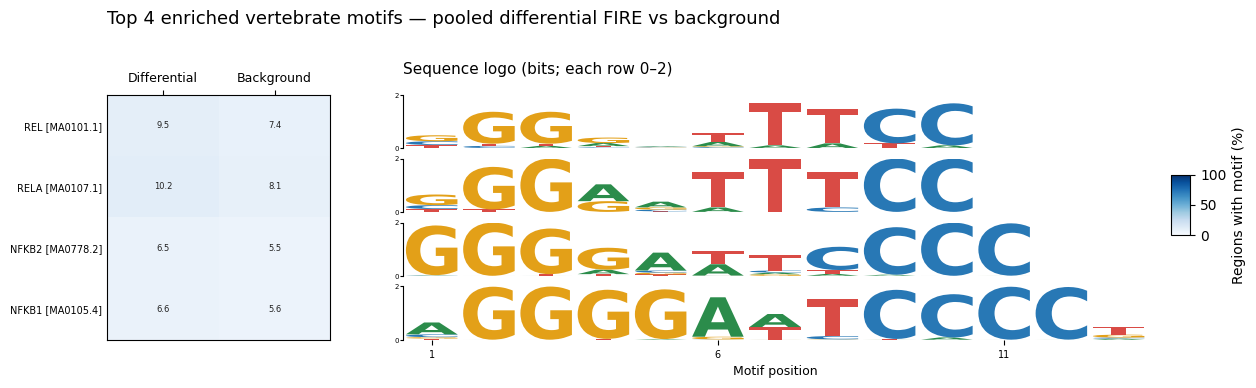

In [37]:
if not top_motifs.empty:
    logo_figure = plot_motif_heatmap_and_logos(top_motifs, motif_probabilities)
    logo_figure.savefig(enrichment_dir / 'top100_motif_heatmap_logos.pdf', bbox_inches='tight')
    logo_figure.savefig(enrichment_dir / 'top100_motif_heatmap_logos.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(logo_figure)
else:
    print('Heatmap/logos: waiting for results, or no motifs meet the enrichment cutoff.')


### 2. Top enriched motifs: odds-ratio lollipop plot

The x-axis is odds ratio on a logarithmic scale; the reference line is OR = 1.
Point color shows shared versus differential-only status. Triangles flag
zero-cell tables whose plotted odds ratios use the 0.5 correction described
above. Exact, potentially infinite odds ratios are available in the result TSV.


In [38]:
def plot_motif_lollipops(top_table):
    """Plot finite odds ratios while identifying corrected zero-cell tables."""
    fig, ax = plt.subplots(figsize=(12, max(4, 0.29 * len(top_table) + 1.5)))
    y = np.arange(len(top_table))
    palette = {'shared': '#3274a1', 'differential-only': '#dd8452'}
    ax.hlines(y, 1, top_table['odds_ratio_plot'], color='#c7c7c7', linewidth=1.1)
    for status, color in palette.items():
        for corrected, marker in [(False, 'o'), (True, '^')]:
            keep = (top_table['motif_status'] == status) & (top_table['zero_cell_correction'] == corrected)
            if keep.any():
                ax.scatter(top_table.loc[keep, 'odds_ratio_plot'], y[keep], color=color,
                           marker=marker, s=35, zorder=3,
                           label=status + (' (0.5 correction)' if corrected else ''))
    ax.axvline(1, color='#555555', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_yticks(y, top_table['label'], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Odds ratio: differential vs background (log scale)')
    ax.set_title(f'Top {len(top_table)} enriched motifs (BH q < {fdr_threshold})')
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='best', fontsize=8)
    fig.tight_layout()
    return fig


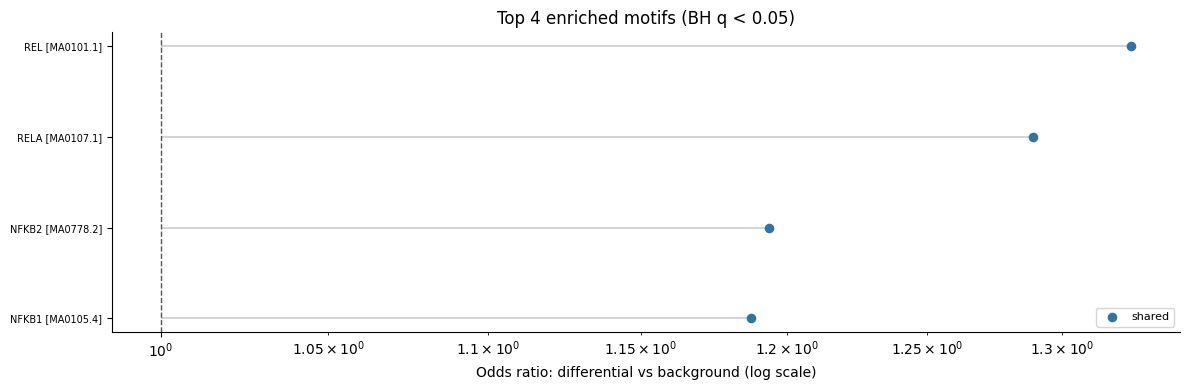

In [39]:
if not top_motifs.empty:
    lollipop_figure = plot_motif_lollipops(top_motifs)
    lollipop_figure.savefig(enrichment_dir / 'top100_motif_odds_ratios.pdf', bbox_inches='tight')
    lollipop_figure.savefig(enrichment_dir / 'top100_motif_odds_ratios.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(lollipop_figure)
else:
    print('Lollipop plot: waiting for results, or no motifs meet the enrichment cutoff.')


### 3. Shared and differential-only motif enrichment

Plot the same top significant motifs: x = log2 odds ratio and y = −log10(raw
one-sided Fisher p). Colors distinguish motifs found in both region sets from
those with no background hit. Point area increases with differential-region
prevalence; labels identify the ten highest-ranked motifs. The significance
selection is BH q < 0.05, even though the y-axis shows raw p. Numerically zero
p-values are capped at −log10(the smallest positive normal float).


In [40]:
def plot_shared_unique_enrichment(top_table):
    """Plot enrichment strength and significance by motif detection category."""
    fig, ax = plt.subplots(figsize=(11, 7))
    palette = {'shared': '#3274a1', 'differential-only': '#dd8452'}
    for status, color in palette.items():
        subset = top_table.loc[top_table['motif_status'] == status]
        if not subset.empty:
            ax.scatter(subset['log2_odds_ratio_plot'], subset['neg_log10_p'],
                       s=30 + 150 * subset['differential_fraction'], c=color, alpha=0.8,
                       edgecolors='white', linewidths=0.5, label=f'{status} (n={len(subset)})')
    # Place labels in a separate right margin so clustered significant motifs remain legible.
    labels = top_table.head(10).sort_values('neg_log10_p', ascending=False)
    for i, (_, row) in enumerate(labels.iterrows()):
        ax.annotate(row['label'], (row['log2_odds_ratio_plot'], row['neg_log10_p']),
                    xytext=(1.02, 0.92 - i * 0.078), textcoords='axes fraction', fontsize=8,
                    va='center', annotation_clip=False,
                    arrowprops={'arrowstyle': '-', 'color': '#aaaaaa', 'lw': 0.6})
    ax.axvline(0, color='#777777', linestyle='--', linewidth=1)
    ax.set_xlabel('log2 odds ratio: differential vs background (0.5 correction for zero cells)')
    ax.set_ylabel('−log10(Fisher enrichment p-value)')
    ax.set_title(f'Top {len(top_table)} significant motifs: shared vs differential-only')
    ax.legend(title='Detection at FIMO p ≤ 1e-4', fontsize=9, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(x=0.2, y=0.2)
    fig.subplots_adjust(left=0.1, right=0.74, bottom=0.13, top=0.92)
    return fig


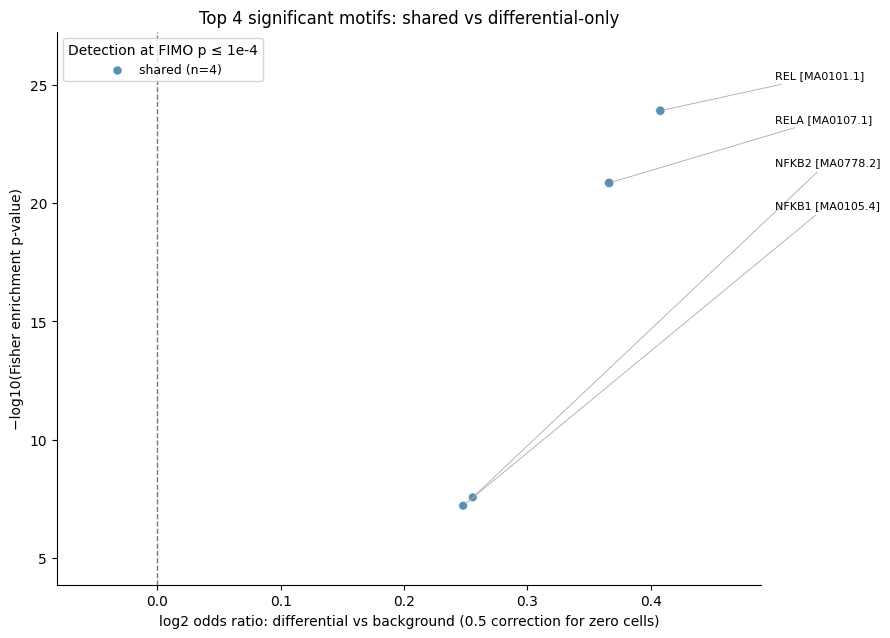

Result tables, region/motif count matrices, and figures saved to /project/spott/cshan/fiber-seq/macrophage_project/fire_frequency/tf_motif/enrichment_vertebrates


In [41]:
if not top_motifs.empty:
    shared_unique_figure = plot_shared_unique_enrichment(top_motifs)
    shared_unique_figure.savefig(enrichment_dir / 'top100_shared_unique_enrichment.pdf', bbox_inches='tight')
    shared_unique_figure.savefig(enrichment_dir / 'top100_shared_unique_enrichment.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(shared_unique_figure)
    print(f'Result tables, region/motif count matrices, and figures saved to {enrichment_dir}')
else:
    print('Shared/unique plot: waiting for results, or no motifs meet the enrichment cutoff.')


### 4. Expression of the top 100 significant TF genes across time

Select up to 100 **unique human TF genes** associated with significant,
expression-eligible motifs. Rank a gene by its best enriched motif's BH q,
then Fisher p and odds ratio; multiple profiles for one TF do not create
duplicate gene rows. A complex contributes its mapped component genes.
These are motif-enrichment rankings, not RNA differential-expression tests.

Plot **log2(mean CPM + 1)**, with genes in enrichment rank order and time
points in chronological order. Means are calculated before the log transform.
The color scale is absolute expression (no row z-scoring). Raw per-time means,
replicate CPM, and each gene's best associated motif are exported as TSVs.


In [30]:
def select_top_enriched_tf_genes(results, components, limit=100):
    """Rank unique expressed human TF genes by their best significant motif."""
    significant = results.loc[results['significant_enrichment'],
                              ['motif_id', 'q_value', 'p_value', 'odds_ratio']]
    mapped = components.dropna(subset=['gene_name'])[['motif_id', 'gene_name']].drop_duplicates()
    ranked = significant.merge(mapped, on='motif_id', validate='one_to_many')
    return (ranked.sort_values(['q_value', 'p_value', 'odds_ratio', 'gene_name'],
                               ascending=[True, True, False, True])
            .drop_duplicates('gene_name').head(limit).reset_index(drop=True))


In [31]:
top_tf_genes = pd.DataFrame()
if enrichment_results is not None:
    top_tf_genes = select_top_enriched_tf_genes(enrichment_results, motif_tf_components, top_n)
    top_tf_genes.to_csv(enrichment_dir / 'top100_significant_tf_genes.tsv', sep='\t', index=False)
    top_tf_expression = gene_time_mean_cpm.reindex(top_tf_genes['gene_name'])
    top_tf_expression.to_csv(enrichment_dir / 'top100_tf_mean_cpm_by_time.tsv', sep='\t')
    print(f'{len(top_tf_genes)} unique TF genes selected from significant motifs.')
    display(top_tf_genes.head(15))
    display(top_tf_expression.head(15).round(2))
else:
    print('Top significant TF expression: waiting for both FIMO scans. Replicate/time expression tables are already available.')


4 unique TF genes selected from significant motifs.


,motif_id,q_value,p_value,odds_ratio,gene_name
0,MA0101.1,6.517531e-22,1.268002e-24,1.326576,REL
1,MA0107.1,3.643282e-19,1.417620e-21,1.288956,RELA
2,MA0778.2,4.574058e-06,2.669683e-08,1.193875,NFKB2
3,MA0105.4,7.745100e-06,6.027315e-08,1.187419,NFKB1


time_min,0,5,10,15
gene_name,,,,
REL,21.00,21.64,21.29,22.80
RELA,81.05,80.87,78.92,83.57
NFKB2,43.78,45.00,41.75,45.18
NFKB1,67.95,68.03,65.69,67.06


In [32]:
def plot_tf_expression_timecourse(mean_cpm, ranked_genes):
    """Heatmap of log2 arithmetic-mean replicate CPM + 1, without row scaling."""
    values = mean_cpm.reindex(ranked_genes['gene_name'])
    if values.empty or values.isna().any().any():
        raise ValueError('Missing expression for a selected TF gene')
    log_values = np.log2(values.to_numpy() + 1)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(values) + 1.5)))
    heat = ax.imshow(log_values, cmap='magma', aspect='auto', vmin=0)
    ax.set_xticks(np.arange(len(values.columns)), [f'{time} min' for time in values.columns])
    ax.set_yticks(np.arange(len(values)), values.index, fontsize=7)
    ax.set_xlabel('LPS time point (mean of three biological replicates)')
    ax.set_ylabel('TF gene; ranked by best enriched motif')
    ax.set_title(f'Expression of top {len(values)} TF genes associated with enriched motifs')
    fig.colorbar(heat, ax=ax, fraction=0.03, pad=0.03, label='log2(mean CPM + 1)')
    fig.tight_layout()
    return fig


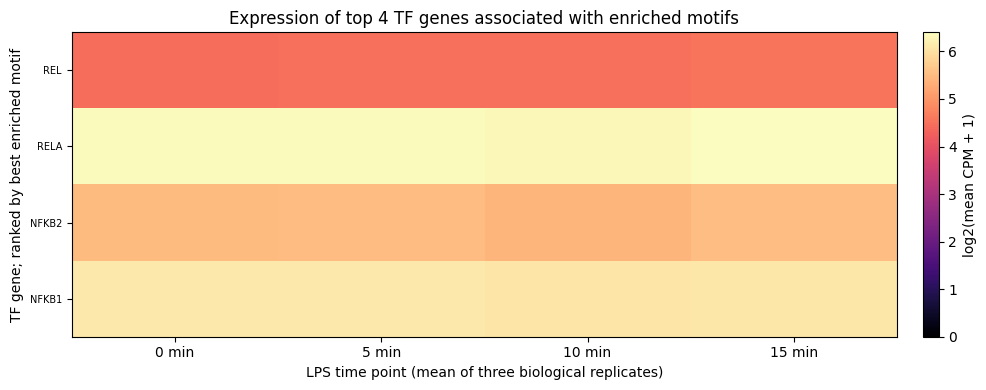

In [33]:
if not top_tf_genes.empty:
    expression_figure = plot_tf_expression_timecourse(gene_time_mean_cpm, top_tf_genes)
    expression_figure.savefig(enrichment_dir / 'top100_tf_expression_timecourse.pdf', bbox_inches='tight')
    expression_figure.savefig(enrichment_dir / 'top100_tf_expression_timecourse.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(expression_figure)
else:
    print('Expression heatmap: waiting for enrichment results, or no expressed TFs have significant motifs.')


### 5. Top enriched motifs by raw Fisher p-value

Select up to 100 expression-eligible motifs with odds ratio > 1 and **raw enrichment p < 0.05**, ranked by raw p, then decreasing odds ratio and motif ID. This is the region-level Fisher p-value, not the site-level FIMO p-value. If fewer than 100 qualify, show all qualifying motifs.

The x-axis shows −log10(raw p), with a dashed line at p = 0.05. Colors distinguish motifs that also pass BH q < 0.05 from those passing only the raw-p cutoff. The existing BH-filtered plots retain their original selection. Export this separate ranking as `motif_enrichment_top100_raw_p.tsv`.


In [1]:
def plot_raw_p_motif_enrichment(top_table, raw_p_cutoff=0.05, bh_cutoff=0.05):
    """Plot raw enrichment significance and distinguish BH-supported motifs."""
    if top_table.empty:
        raise ValueError('No motifs selected for the raw-p plot')
    values = -np.log10(top_table['p_value'].clip(lower=np.finfo(float).tiny))
    y = np.arange(len(top_table))
    fig, ax = plt.subplots(figsize=(12, max(4, 0.30 * len(top_table) + 2)))
    ax.hlines(y, 0, values, color='#c7c7c7', linewidth=1.2)
    bh_pass = top_table['q_value'].lt(bh_cutoff)
    for keep, color, label in [
        (bh_pass, '#3274a1', f'Also BH q < {bh_cutoff}'),
        (~bh_pass, '#dd8452', f'Raw p only (BH q ≥ {bh_cutoff})'),
    ]:
        if keep.any():
            ax.scatter(values.loc[keep], y[keep.to_numpy()], color=color, s=38,
                       zorder=3, label=f'{label}; n={int(keep.sum())}')
    ax.axvline(-np.log10(raw_p_cutoff), color='#555555', linestyle='--', linewidth=1,
               label=f'Raw p = {raw_p_cutoff}')
    ax.set_yticks(y, top_table['label'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(left=0)
    ax.set_xlabel('−log10(raw Fisher enrichment p-value)')
    ax.set_title(f'Top {len(top_table)} motifs ranked by raw enrichment p-value\n'
                 f'Expressed TFs; odds ratio > 1; raw p < {raw_p_cutoff}', fontsize=12)
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()
    return fig


In [2]:
raw_p_threshold = 0.05
raw_p_candidates = enrichment_results.loc[
    enrichment_results['expressed_any_time']
    & enrichment_results['odds_ratio'].gt(1)
    & enrichment_results['p_value'].lt(raw_p_threshold)
].sort_values(['p_value', 'odds_ratio', 'motif_id'], ascending=[True, False, True])
top_raw_p_motifs = raw_p_candidates.head(top_n).copy()
top_raw_p_motifs.to_csv(enrichment_dir / 'motif_enrichment_top100_raw_p.tsv', sep='\t', index=False)
print(f'{len(raw_p_candidates)} expression-eligible motifs have raw p < {raw_p_threshold} and OR > 1; '
      f'plotting {len(top_raw_p_motifs)} (up to {top_n}).')
print(f'{top_raw_p_motifs["q_value"].lt(fdr_threshold).sum()} plotted motifs also pass BH q < {fdr_threshold}.')
display(top_raw_p_motifs[['motif_id', 'TF', 'odds_ratio', 'p_value', 'q_value']].head(10))


27 expression-eligible motifs have raw p < 0.05 and OR > 1; plotting 27 (up to 100).
4 plotted motifs also pass BH q < 0.05.


,motif_id,TF,odds_ratio,p_value,q_value
0,MA0101.1,REL,1.326576,1.268002e-24,6.517531e-22
1,MA0107.1,RELA,1.288956,1.417620e-21,3.643282e-19
2,MA0778.2,NFKB2,1.193875,2.669683e-08,4.574058e-06
3,MA0105.4,NFKB1,1.187419,6.027315e-08,7.745100e-06
4,MA0497.2,MEF2C,1.092421,8.014524e-04,8.238930e-02
5,MA1955.2,FOXO1::ELK3,1.078252,1.020143e-03,8.739221e-02
6,MA1624.2,Stat5a,1.094158,1.444654e-03,1.060789e-01
7,MA0773.1,MEF2D,1.091503,3.505322e-03,2.252170e-01
8,MA0052.5,MEF2A,1.077775,4.458124e-03,2.546084e-01
9,MA0137.4,STAT1,1.081544,5.753062e-03,2.957074e-01


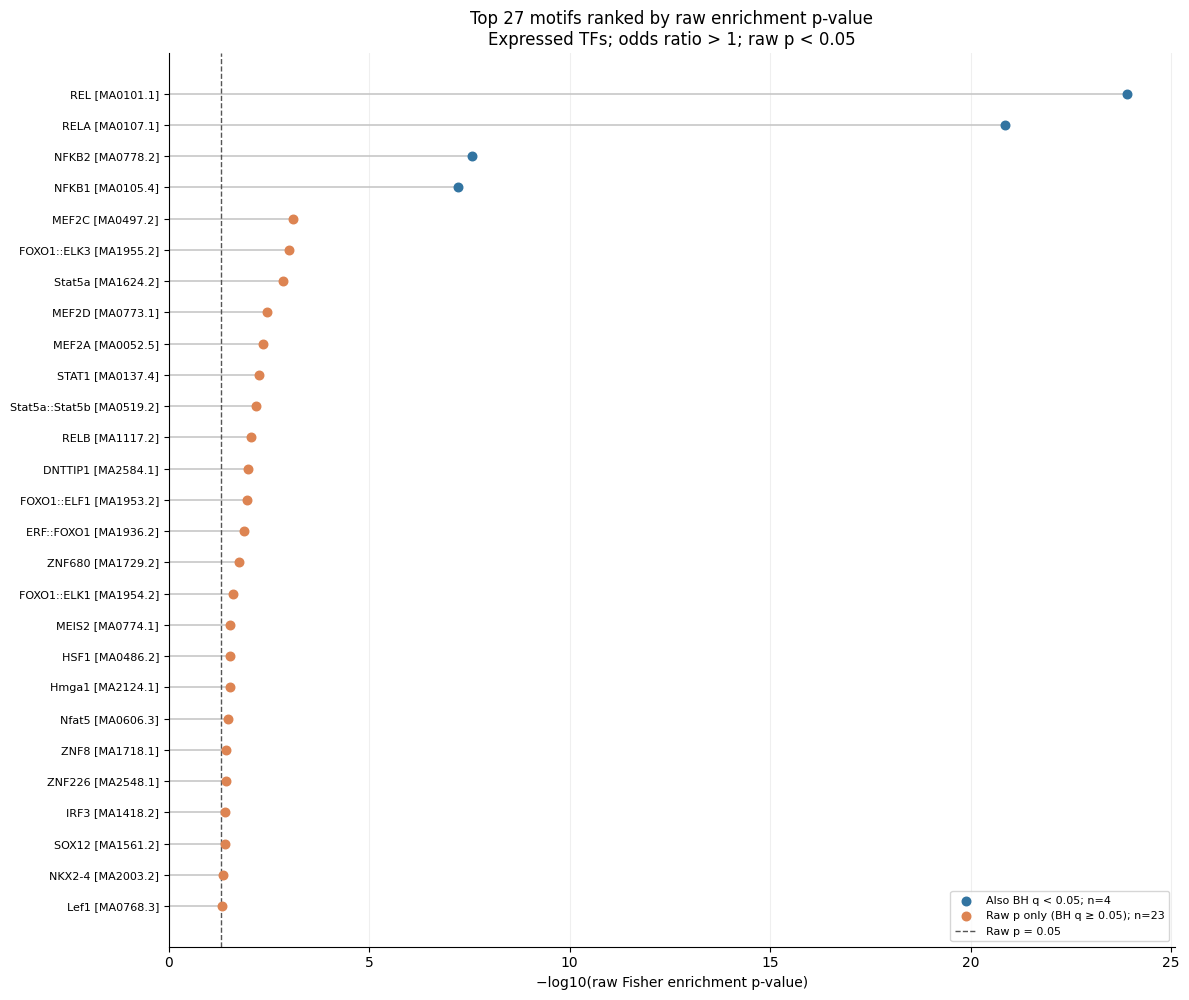

In [3]:
if not top_raw_p_motifs.empty:
    raw_p_figure = plot_raw_p_motif_enrichment(top_raw_p_motifs, raw_p_threshold, fdr_threshold)
    raw_p_figure.savefig(enrichment_dir / 'top100_motif_raw_p.pdf', bbox_inches='tight')
    raw_p_figure.savefig(enrichment_dir / 'top100_motif_raw_p.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(raw_p_figure)
else:
    print('Raw-p plot: no expressed-TF motifs meet raw p < 0.05 and odds ratio > 1.')
